In [22]:
import torch
from torchvision import transforms

import uconn_ballots_dino_v3_model
import uccon_ballots_dataset
from warmup_cosine_annealing_lr import WarmupCosineAnnealingLR
from validate_uconn_dataset import validate_uconn, validate_model, validate_dataset, validate_model_loads_dataset
from train_helper_funcs import ProgressTracker, CheckpointManager, _count_correct, _compute_accuracy


DATASET_ROOT = "./uconn_voter_center_v2_2/FINALDATASETV3/preprint/" # Path to the root directory containing the dataset .pth files, using preprint version as default
VARIANT = "Combined_Grayscale" # Options: "Combined_Grayscale", "Combined_RGB", "OnlyBubbles_Grayscale", "OnlyBubbles_RGB", etc

# CHECKPOINTING
SAVE_CHECKPOINTS = True
CHECKPOINT_DIR = "./checkpoints/"
CHECKPOINT_MODE = "best"  # Options: "best", "last", "both"

class Ensure3Channels:
    def __call__(self, x):
        if x.shape[0] == 1:
            return x.repeat(3, 1, 1)
        return x
    
# Define data augmentations/transforms:
augmentations = transforms.Compose([
        transforms.Resize((224, 224), antialias=True),
        Ensure3Channels(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),# ImageNet normalization
    ])

In [23]:
# Get DataLoaders:
train_loader, val_loader, test_loader = uccon_ballots_dataset.get_uconn_dataloaders(
    batch_size=32,
    test_size=5000,
    test_source="val",
    variant=VARIANT,
    print_option="postprint",
    transform=augmentations,
    val_transform=augmentations,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
    seed=42,
)


Created test split → D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3\split_Combined_Grayscale.txt (5000 samples)
Variant:    Combined_Grayscale  |  channels: 1
Train size: 42679
Val size:   5652
Test size:  5000
Root:       D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3


In [24]:
# Load best model for final evaluation on test set

best_model_path = "./checkpoints/checkpoints/best.pt"
best_model = uconn_ballots_dino_v3_model.DINOv3UConnModel(num_classes=2)
best_model.load_state_dict(torch.load(best_model_path)["model_state_dict"])
best_model = best_model.to('cuda' if torch.cuda.is_available() else 'cpu')
best_model.eval()

criterion = torch.nn.CrossEntropyLoss()

test_loss = 0.0
test_correct = 0
test_samples = 0
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Evaluate on test set without tracking gradients
with torch.inference_mode():
    for batch in test_loader:
        data, target, *_ = batch
        data, target = data.to(device), target.to(device)

        preds = best_model(data)
        loss = criterion(preds, target)
        test_loss += loss.item()

        test_correct += _count_correct(preds, target)
        test_samples += target.size(0)

mean_test_loss = test_loss / len(test_loader)
test_acc = _compute_accuracy(test_correct, test_samples)

print(f"TEST Loss: {mean_test_loss:.4f} | Test Acc: {test_acc:.4%}")


TEST Loss: 0.0576 | Test Acc: 98.6400%


Incorrect predictions: 68 / 5000


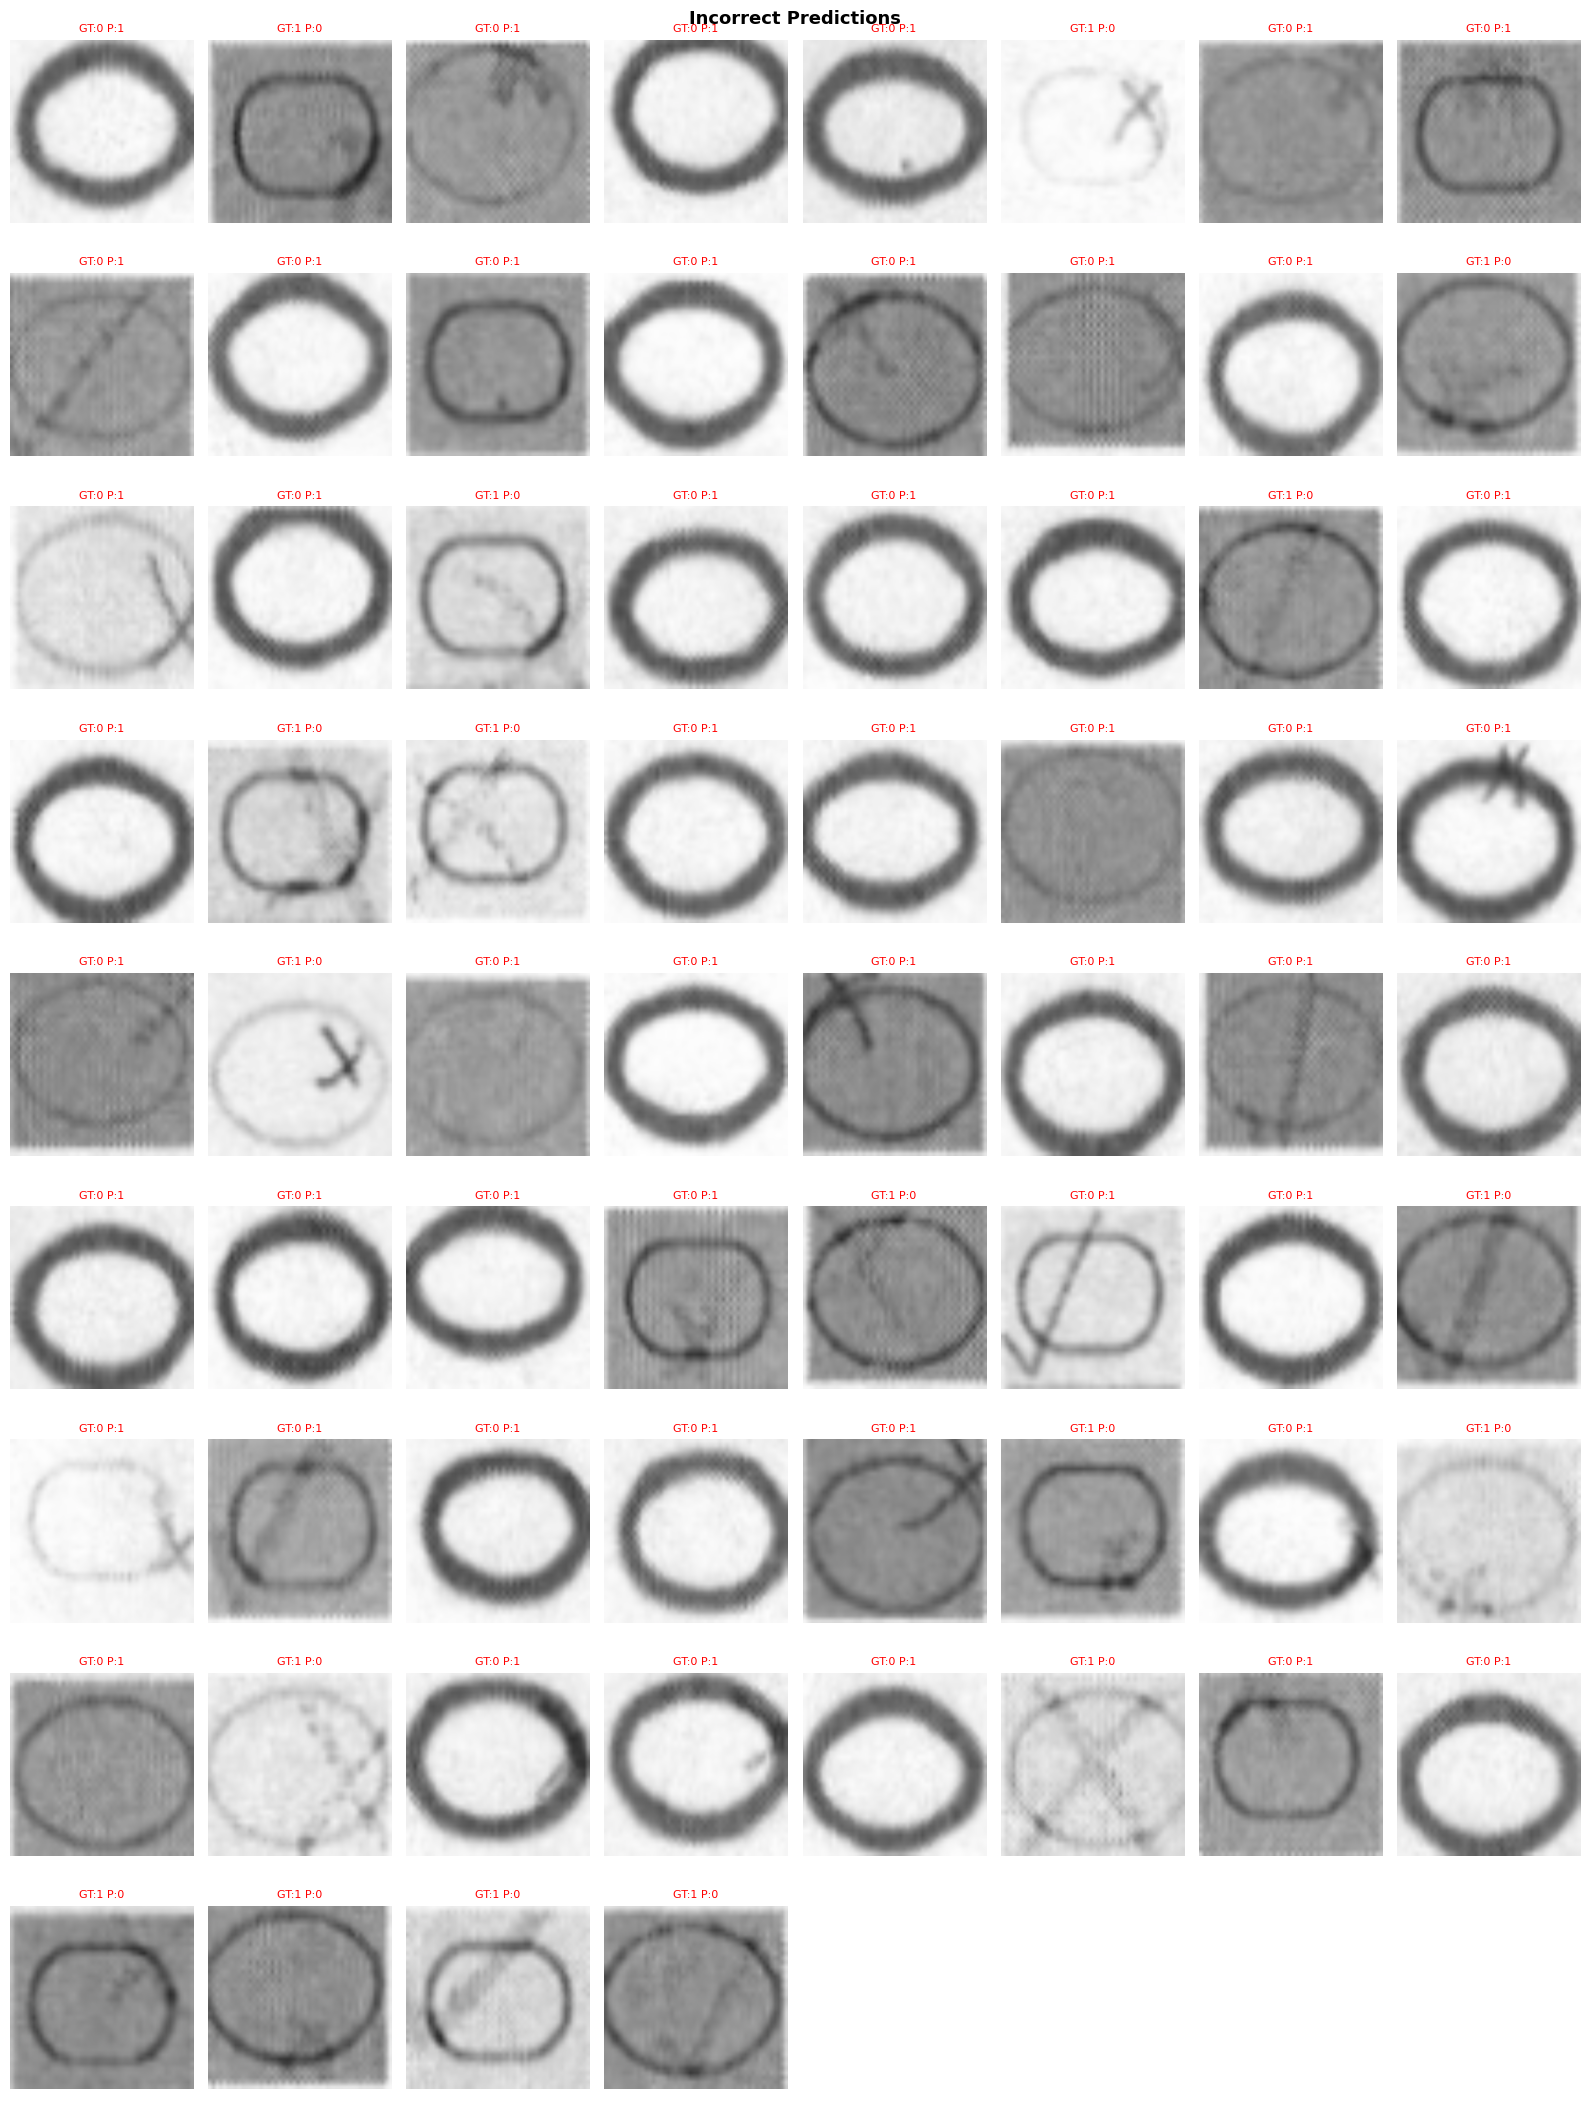

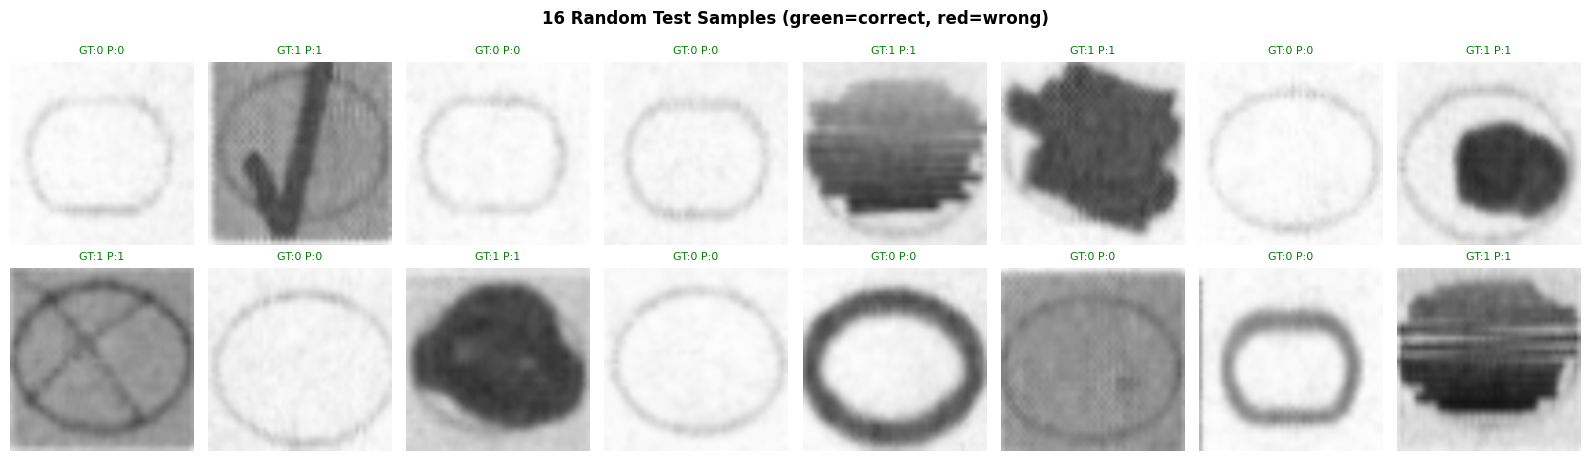

In [25]:
import matplotlib.pyplot as plt
import math

def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone().cpu().float()
    for c, m, s in zip(range(t.shape[0]), mean, std):
        t[c] = t[c] * s + m
    return t.permute(1, 2, 0).clamp(0, 1).numpy()

# Collect ALL test-set predictions
all_images, all_labels, all_preds = [], [], []

best_model.eval()
with torch.inference_mode():
    for batch in test_loader:
        imgs, lbls, *_ = batch
        imgs, lbls = imgs.to(device), lbls.to(device)
        out = best_model(imgs)
        pred = torch.argmax(out, dim=1)
        all_images.append(imgs.cpu())
        all_labels.append(lbls.cpu())
        all_preds.append(pred.cpu())

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_preds  = torch.cat(all_preds)

# Plot 1: All incorrect predictions
wrong_mask   = all_preds != all_labels
wrong_images = all_images[wrong_mask]
wrong_labels = all_labels[wrong_mask]
wrong_preds  = all_preds[wrong_mask]

n_wrong = len(wrong_images)
print(f"Incorrect predictions: {n_wrong} / {len(all_labels)}")

if n_wrong == 0:
    print("No incorrect predictions to display.")
else:
    cols = min(8, n_wrong)
    rows = math.ceil(n_wrong / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.4))
    axes = [axes] if rows == 1 and cols == 1 else axes
    axes_flat = [axes] if n_wrong == 1 else (axes if rows == 1 else [ax for row in axes for ax in row])
    for i, ax in enumerate(axes_flat):
        if i < n_wrong:
            ax.imshow(denormalize(wrong_images[i]))
            ax.set_title(f"GT:{wrong_labels[i].item()} P:{wrong_preds[i].item()}", fontsize=8, color="red")
        ax.axis("off")
    fig.suptitle("Incorrect Predictions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Plot 2: N random samples from test set
N_RANDOM = 16
cols = min(8, N_RANDOM)
rows = math.ceil(N_RANDOM / cols)

indices = torch.randperm(len(all_images))[:N_RANDOM]
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.4))
axes_flat = [ax for row in axes for ax in row] if rows > 1 else list(axes)
for i, ax in enumerate(axes_flat):
    idx = indices[i].item()
    correct = all_preds[idx] == all_labels[idx]
    color = "green" if correct else "red"
    ax.imshow(denormalize(all_images[idx]))
    ax.set_title(f"GT:{all_labels[idx].item()} P:{all_preds[idx].item()}", fontsize=8, color=color)
    ax.axis("off")
fig.suptitle(f"{N_RANDOM} Random Test Samples (green=correct, red=wrong)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
